In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [23]:
df = pd.read_csv('cleaned_dataset_sample.csv')

In [24]:
print(df.head())
print(df.columns)

  symbol        date    open     high     low   close   volume
0    vno  2016-12-19  103.89  104.790  103.51  103.91  1123277
1    nbl  2014-09-17   71.50   71.630   70.58   71.17  1955639
2    flr  2016-01-04   46.53   47.760   46.26   47.71  1645312
3    whr  2015-11-12  157.16  157.160  155.10  155.50   800809
4    dri  2016-01-06   62.83   63.605   62.56   62.92  2001050
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [25]:
df_encoded = pd.get_dummies(df, columns=['symbol'], drop_first=True)

In [26]:
print(df_encoded.columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'symbol_aal',
       'symbol_aap', 'symbol_aapl', 'symbol_abbv',
       ...
       'symbol_xl', 'symbol_xlnx', 'symbol_xom', 'symbol_xray', 'symbol_xrx',
       'symbol_xyl', 'symbol_yum', 'symbol_zbh', 'symbol_zion', 'symbol_zts'],
      dtype='object', length=508)


In [27]:
X = df_encoded.drop(['close', 'date'], axis=1)  # 'Close' target, 'Date' drop
y = df_encoded['close']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 506)
Testing set: (1000, 506)


In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients & Intercept
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
print("Model Coefficients:\n", coef_df)
print("Intercept:", model.intercept_)

Model Coefficients:
          Feature   Coefficient
0           open -5.657375e-01
1           high  8.991934e-01
2            low  6.668252e-01
3         volume -3.005817e-09
4     symbol_aal  7.261586e-03
..           ...           ...
501   symbol_xyl -1.722868e-02
502   symbol_yum  4.521693e-02
503   symbol_zbh -7.111000e-02
504  symbol_zion  1.930664e-01
505   symbol_zts -1.306650e-01

[506 rows x 2 columns]
Intercept: -0.14501920774338828


In [31]:
y_pred = model.predict(X_test)

In [32]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

R-squared: 0.9999360424251332
Mean Squared Error: 0.758437008623196


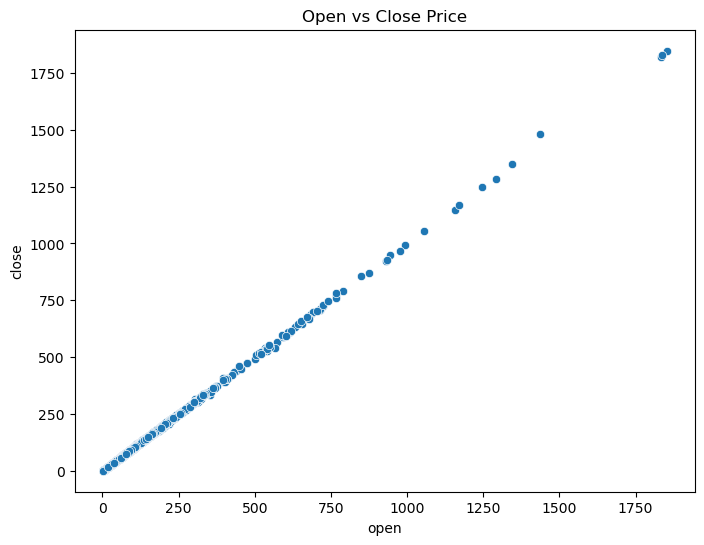

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='open', y='close', data=df)
plt.title('Open vs Close Price')
plt.show()


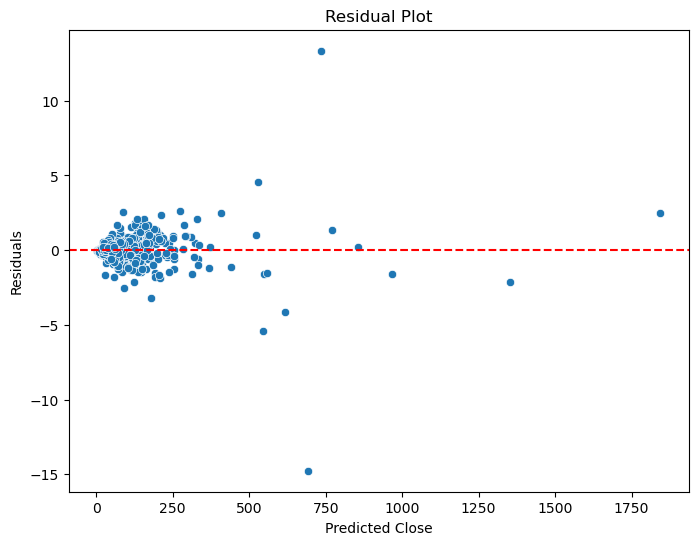

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Close')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

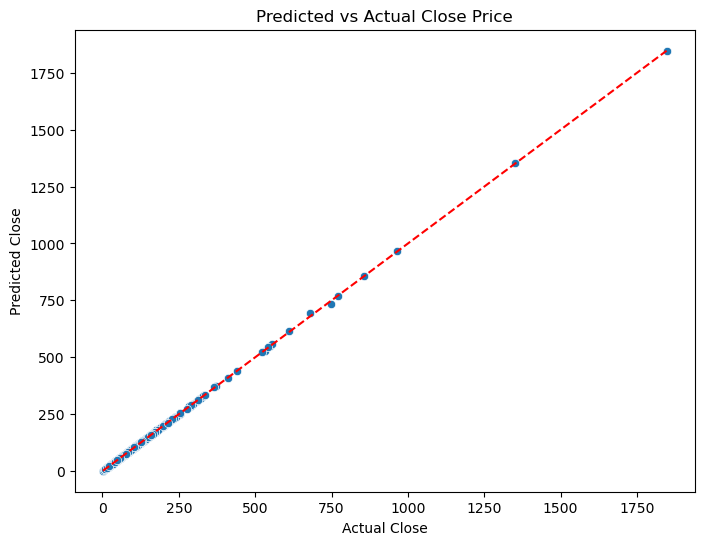

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Close')
plt.ylabel('Predicted Close')
plt.title('Predicted vs Actual Close Price')
plt.show()